In [14]:
import numpy as np
import pickle
import torch
import time
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
import src.learning as lrn
from src.safetymaps import StaticSafetyMap, DynamicSafetyMap, StaticNoisedSafetyMap, DesignedSafetyMap
from src.reachsteering import HdaGreedy, HdaReachSteering
from src.visualization import *
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
def visualize_traj(hda):
    t, X, U = hda.construct_trajectory()
    fig, axs = plot_3sides(t[:-1], X, U=None, uskip=1)
    n_traj = len(hda.X_list)
    for i in range(n_traj):
        t_ = hda.t_list[i]
        X_ = hda.X_list[i]
        U_ = hda.U_list[i]
        fig, axs = plot_3sides(t_[:-1], X_, U=None, uskip=1, fig=fig, axs=axs, linetype='k:')

        axs[0, 0].scatter(X_[0, 0], X_[0, 1], marker='o', color='r')
        axs[1, 0].scatter(X_[0, 0], X_[0, 2], marker='o', color='r')
        axs[1, 1].scatter(X_[0, 1], X_[0, 2], marker='o', color='r')

    # tight layout
    plt.tight_layout()

    return fig, axs

def visualize_profiles(hda, lander):
    t, X, U = hda.construct_trajectory()
    plot_vel(t, X, lander.vmax)
    plot_mass(t, X, lander.mdry, lander.mwet)
    plot_thrust_mag(t[:-1], U, lander.rho2, lander.rho1)
    plot_pointing(t[:-1], U, lander.pa)
    

In [16]:
def visualize_nn_reach(hda, n_skip=1, fontsize=16):
    # make font times new roman
    plt.rcParams["font.family"] = "Times New Roman"

    sfmap_list = hda.sfmap_list[1:]
    reach_mask_list = hda.reachmask_list
    t_list = hda.t_list

    # skip
    sfmap_list = sfmap_list[::n_skip]
    reach_mask_list = reach_mask_list[::n_skip]
    t_list = t_list[::n_skip]
    # print their len
    print(f'Number of maps: {len(sfmap_list)}')
    print(f'Number of reachability masks: {len(reach_mask_list)}')
    print(f'Number of time steps: {len(t_list)}')
    

    n_map = len(sfmap_list) 
    fig, axs = plt.subplots(1, n_map, figsize=(5*n_map, 6), sharey=True, sharex=True)
    for i in range(n_map):

        sfmap = sfmap_list[i]
        reach_mask = reach_mask_list[i]
        t = t_list[i][0]
    

        n = int(np.sqrt(sfmap.shape[0]))

        x = sfmap[:, 0].reshape(n, n)
        y = sfmap[:, 1].reshape(n, n)
        safety = sfmap[:, 2].reshape(n, n)
        reach_mask = reach_mask.reshape(n, n)

        # Safety Map
        safety_img = axs[i].pcolormesh(x, y, safety, shading='auto', cmap='gray', vmin=0, vmax=1)
        #plt.colorbar(safety_img, ax=axs[i], orientation='vertical', label='Safety')

        # Reachability Set - as the overlay with transparency
        reach_mask[reach_mask <= 0.4] = np.nan
        reachability_img = axs[i].pcolormesh(x, y, reach_mask, shading='auto', cmap='jet', alpha=0.5, vmin=0, vmax=1)
        #plt.colorbar(reachability_img, ax=axs[i], orientation='vertical', label='Reachability')

        axs[i].set_title(f't={t:.0f} s', fontsize=fontsize)
        if i == 0:
            axs[i].set_ylabel('y, m', fontsize=fontsize)
        axs[i].set_xlabel('x, m', fontsize=fontsize)
        axs[i].set_aspect('equal')
        # set font size
        axs[i].tick_params(labelsize=fontsize)


    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([1.0, 0.15, 0.01, 0.7])  # [left, bottom, width, height]
    fig.colorbar(safety_img, ax=axs[-1], cax=cbar_ax)
    # colorbar ticks font size
    cbar_ax.tick_params(labelsize=fontsize)
    # colorbar label
    cbar_ax.set_ylabel("Safety", rotation=270, labelpad=20, fontsize=fontsize)
    # tight layout
    plt.tight_layout()
    return fig, axs

In [47]:
with open('../saved/controllable_set/lander.pkl', 'rb') as f:
        lander = pickle.load(f)

hidden_layers = [256, 256, 256]
nn_reach = lrn.NeuralReach(hidden_layers=hidden_layers)
nn_reach.load_state_dict(torch.load('../saved/controllable_set/reachset_train/20231115-025054/models_20231130-175526/mlp_reach/mlp_reach.pt'))
nn_reach.eval()

#sfmap_model = StaticSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=100)
#sfmap_model = DynamicSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=100, relative_path="..")
#sfmap_model = StaticNoisedSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=100)
sfmap_model = DesignedSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=100,
                                    n_hazards=[50, 50, 400, 2000, 2000],
                                    hazard_sizes=[14, 12,  8, 5, 2])
x0_init = np.array([0.0, 0.0, 1400.0, 5, 5, -45.0, lander.mwet])
tof = 60.0
T = 5.0
dt = 0.5

In [48]:
hda_greedy = HdaGreedy(lander, sfmap_model, nn_reach, border_sharpness=3.0)
hda_greedy.solve_hda(x0_init, tof, T, dt)

x0: [   0.    0. 1400.    5.    5.  -45. 1905.], tgo: 60.0
Greedy HDA optimized single leg: 1.8436598777770996 sec
x0: [  19.94106429   21.15647256 1215.77777629    3.0109123     3.48422978
  -28.59394889 1874.97621844], tgo: 55.0
Greedy HDA optimized single leg: 1.5230650901794434 sec
x0: [ 3.04668666e+01  3.50669082e+01  1.11502672e+03  1.23505127e+00
  2.10231419e+00 -1.16088905e+01  1.84495662e+03], tgo: 50.0
Greedy HDA optimized single leg: 1.3378307819366455 sec
x0: [ 3.56621520e+01  4.34143497e+01  1.07789912e+03  9.22074529e-01
  1.41272733e+00 -8.38536615e+00  1.82682357e+03], tgo: 45.0
Greedy HDA optimized single leg: 1.3659846782684326 sec
x0: [ 3.98308649e+01  4.95236271e+01  1.02368640e+03  7.48681590e-01
  1.03949171e+00 -1.32935005e+01  1.81555303e+03], tgo: 40.0
Greedy HDA optimized single leg: 1.1078548431396484 sec
x0: [ 4.31810810e+01  5.38933959e+01  9.45132910e+02  5.94665822e-01
  7.16915968e-01 -1.81184532e+01  1.80428528e+03], tgo: 35.0
Greedy HDA optimized sing

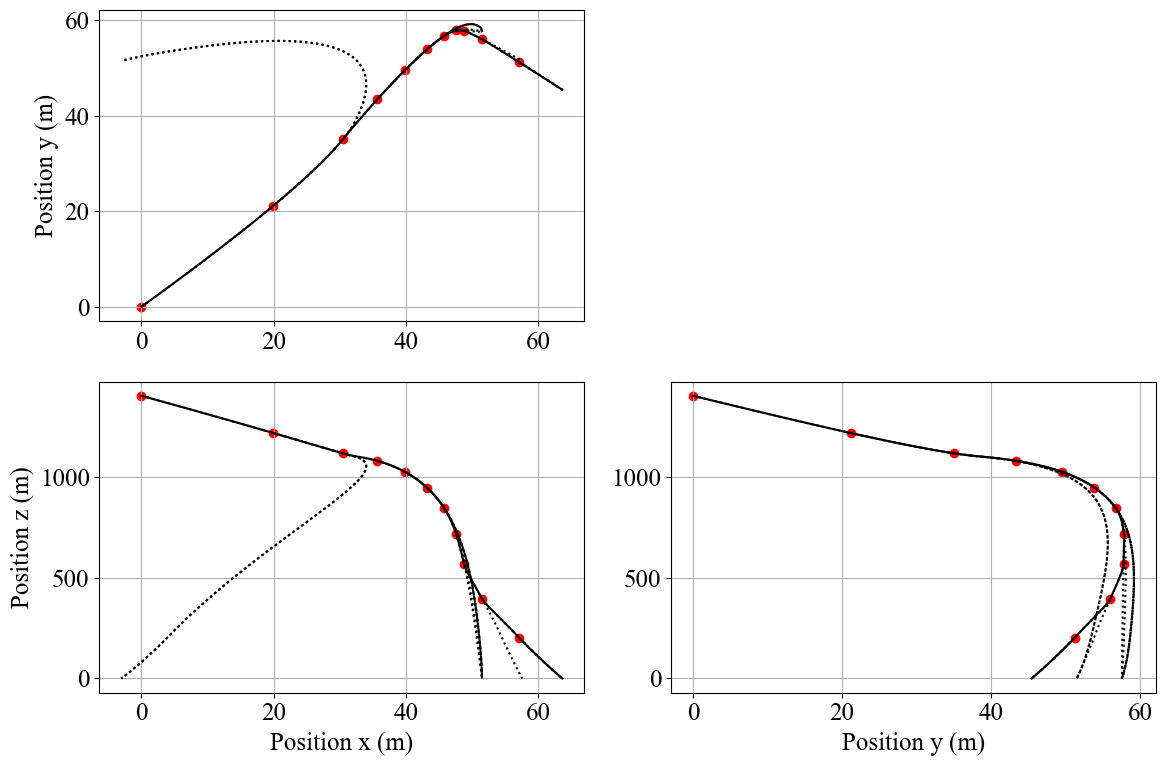

In [49]:
fig, ax = visualize_traj(hda_greedy)
fig.savefig('../saved/fig/traj_greedy.pdf', bbox_inches='tight')


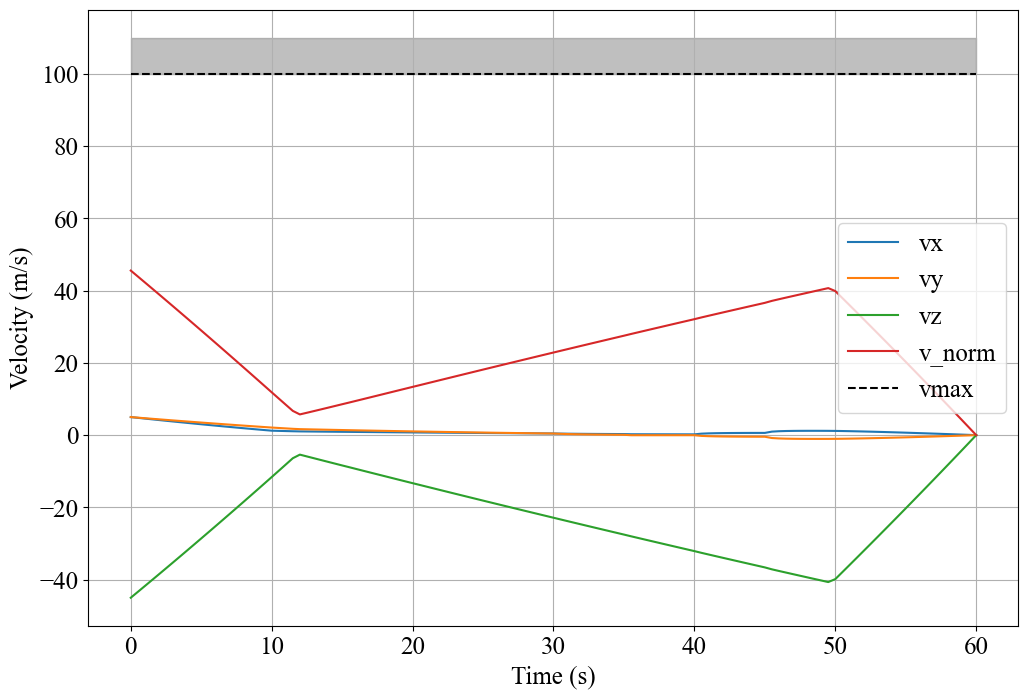

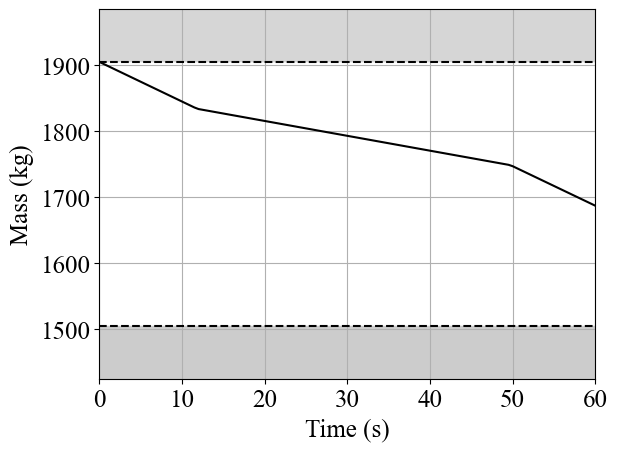

(120,)


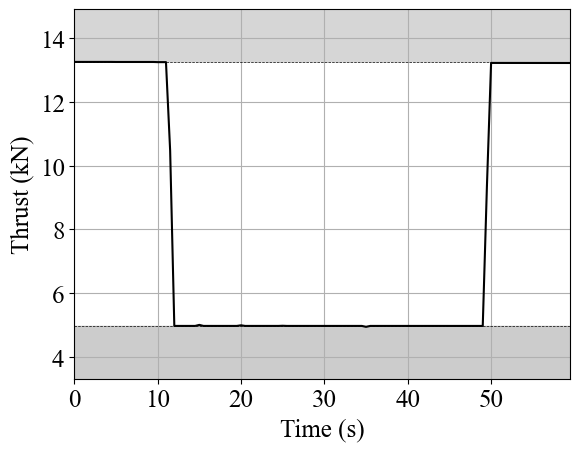

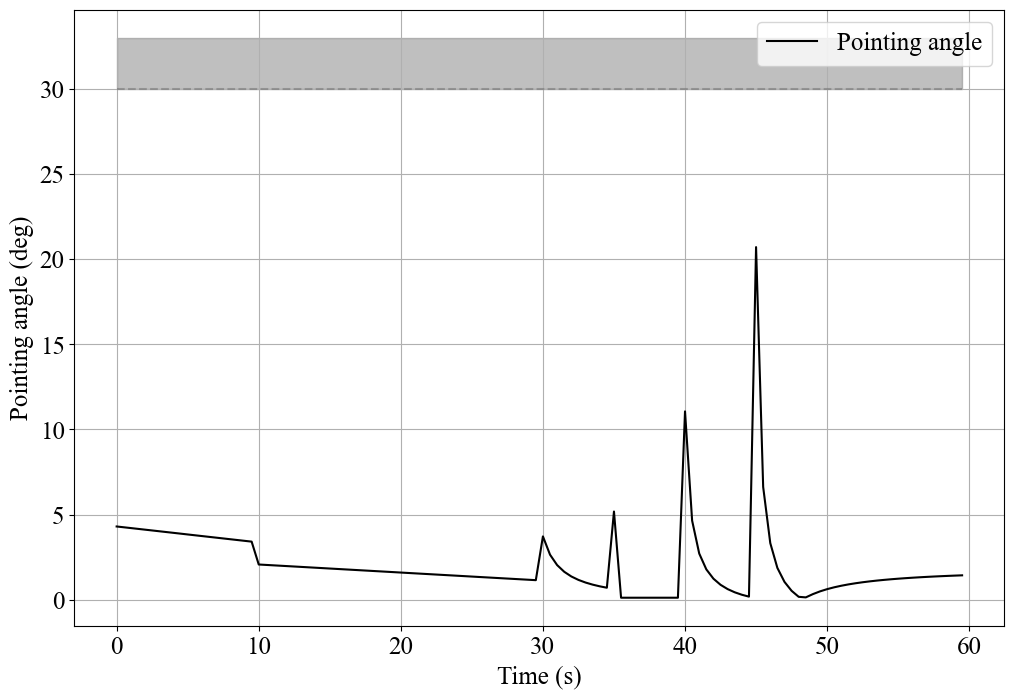

In [50]:
visualize_profiles(hda_greedy, lander)

Number of maps: 6
Number of reachability masks: 6
Number of time steps: 6


C:\Users\ktomita3\AppData\Local\Temp\ipykernel_25756\2361381571.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


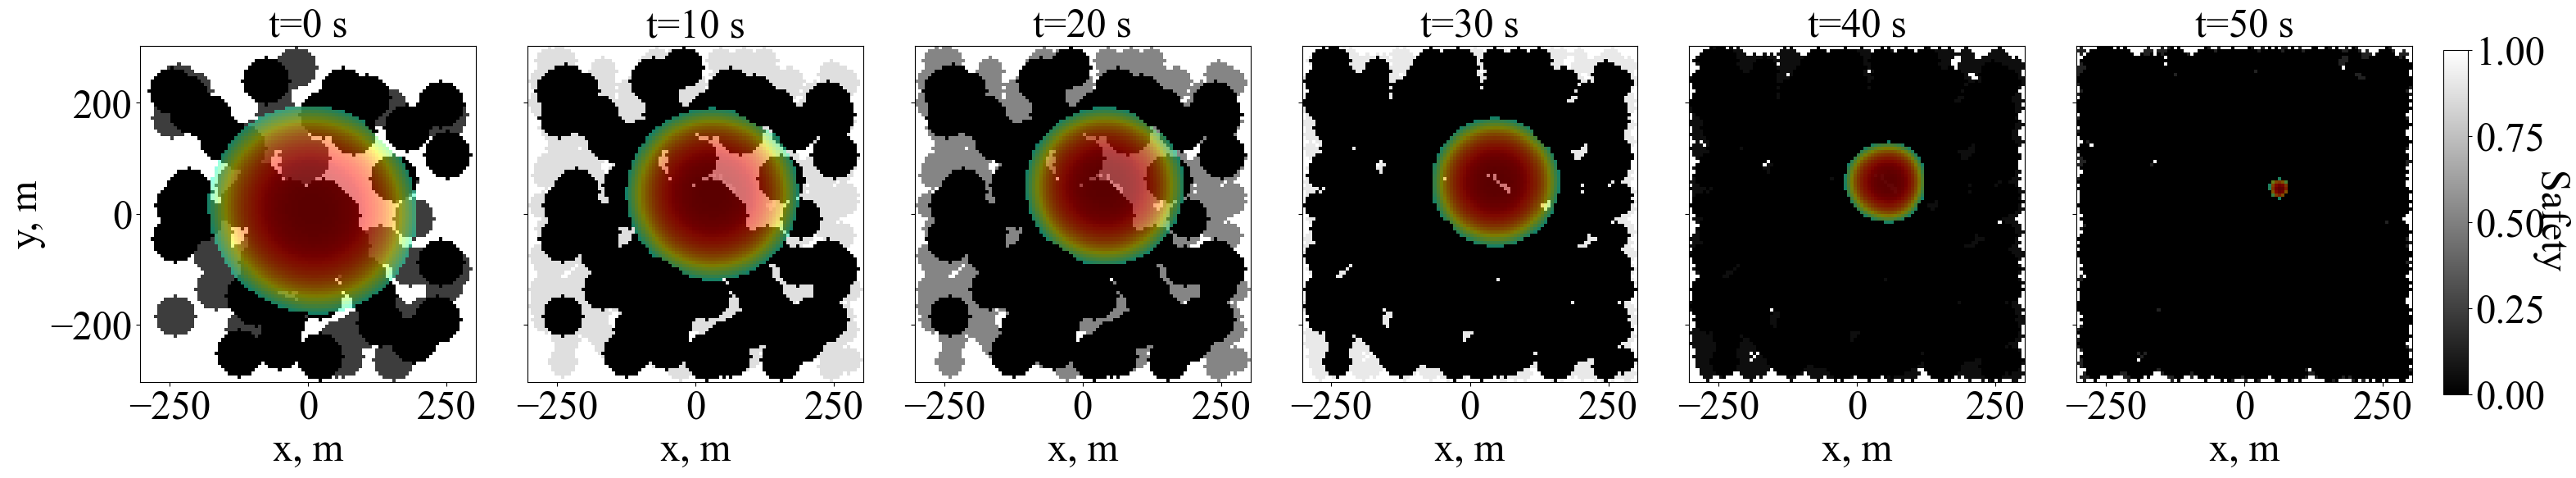

In [51]:
fig, ax = visualize_nn_reach(hda_greedy, n_skip=2, fontsize=35)
#fig.savefig('../saved/fig/reachset_greeedy.pdf', bbox_inches='tight')
# save png as well
fig.savefig('../saved/fig/reachset_greeedy.png', bbox_inches='tight', dpi=500)


In [52]:
hda_rs = HdaReachSteering(lander, sfmap_model, nn_reach, border_sharpness=3.0,
                          itr_max=10000, ftol=1e-12, ctol=1e-8)
hda_rs.solve_hda(x0_init, tof, T, dt)

x0: [   0.    0. 1400.    5.    5.  -45. 1905.], tgo: 60.0
Greedy HDA optimized single leg: 1.6190032958984375 sec
Reach-steering HDA optimized single leg: 1.6536457538604736 sec
x0: [  19.94104653   21.15645902 1215.77808947    3.01090123    3.48422132
  -28.59374986 1874.95236418], tgo: 55.0
Greedy HDA optimized single leg: 1.64571213722229 sec
Reach-steering HDA optimized single leg: 1.6776742935180664 sec
x0: [ 3.04667238e+01  3.50667978e+01  1.11502947e+03  1.23500906e+00
  2.10228126e+00 -1.16080342e+01  1.84490854e+03], tgo: 50.0
Greedy HDA optimized single leg: 1.359346628189087 sec
Reach-steering HDA optimized single leg: 1.394317865371704 sec
x0: [ 3.56619263e+01  4.34142631e+01  1.07790036e+03  9.22071628e-01
  1.41275118e+00 -8.38624444e+00  1.82676650e+03], tgo: 45.0
Greedy HDA optimized single leg: 1.3961694240570068 sec
Reach-steering HDA optimized single leg: 1.4250576496124268 sec
x0: [ 3.98306493e+01  4.95236737e+01  1.02368293e+03  7.48684752e-01
  1.03951340e+00 -1.

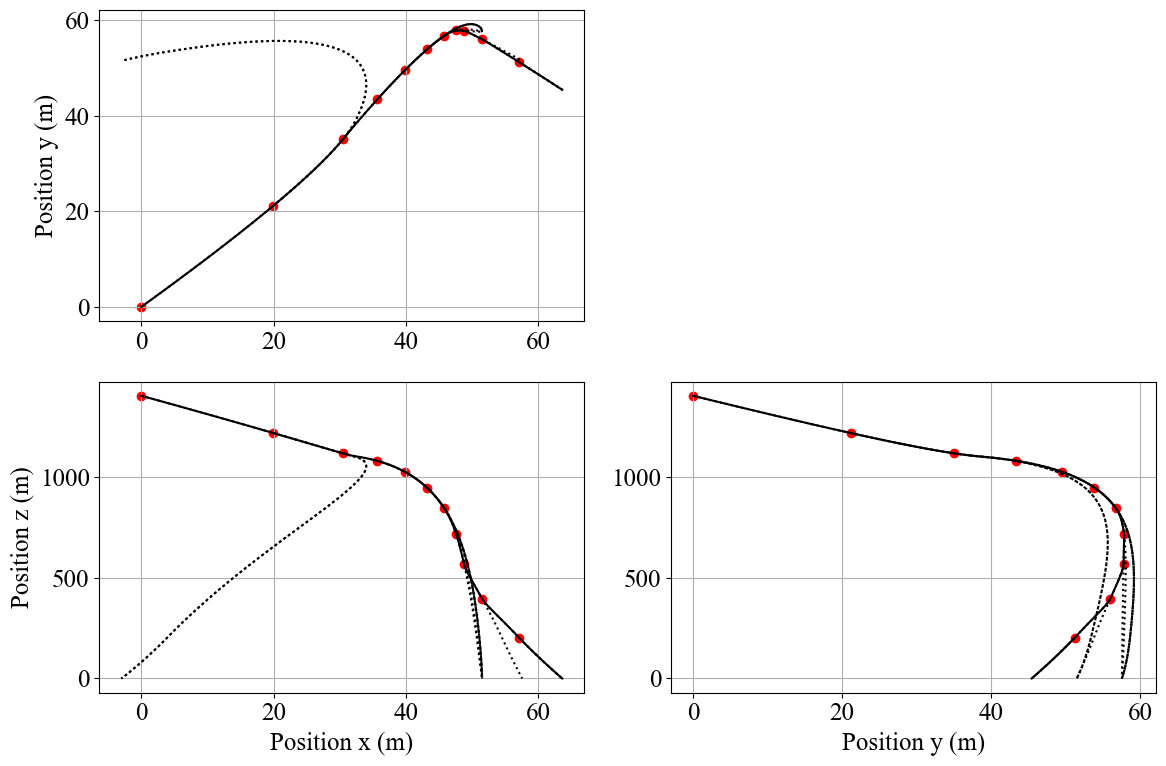

In [53]:
fig, ax = visualize_traj(hda_rs)
fig.savefig('../saved/fig/traj_rs.pdf', bbox_inches='tight')

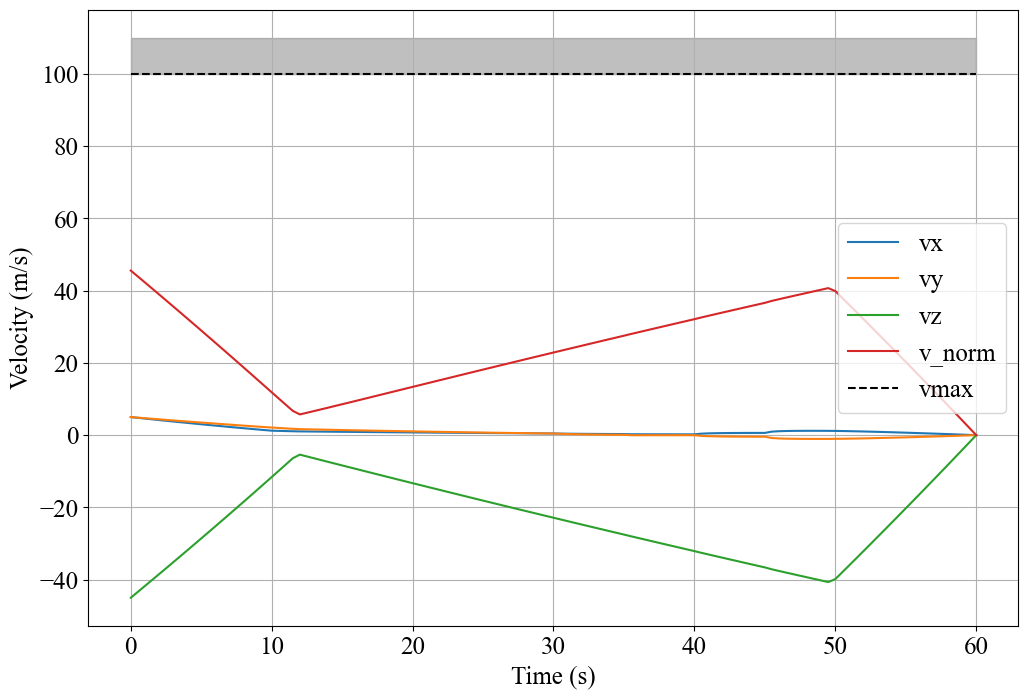

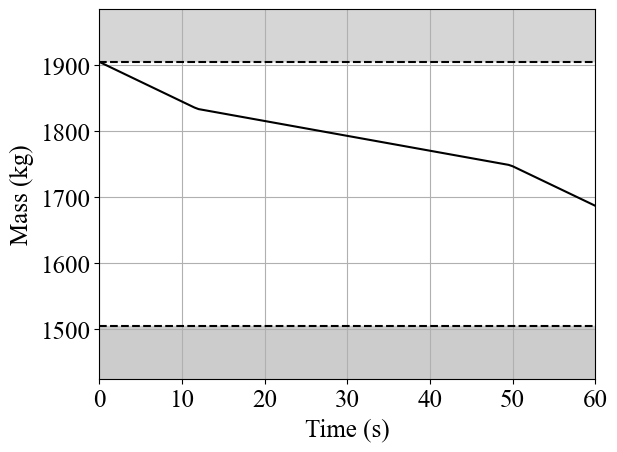

(120,)


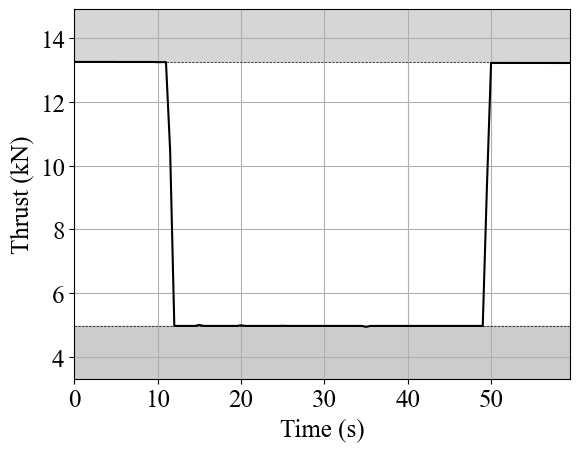

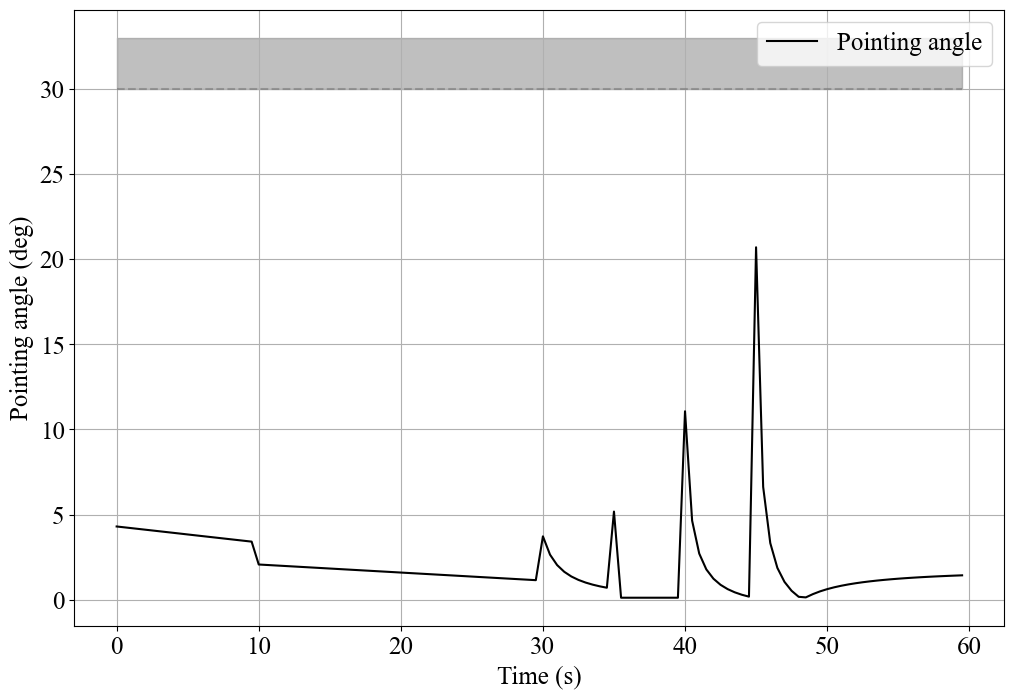

In [54]:
visualize_profiles(hda_rs, lander)

Number of maps: 6
Number of reachability masks: 6
Number of time steps: 6


C:\Users\ktomita3\AppData\Local\Temp\ipykernel_25756\2361381571.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


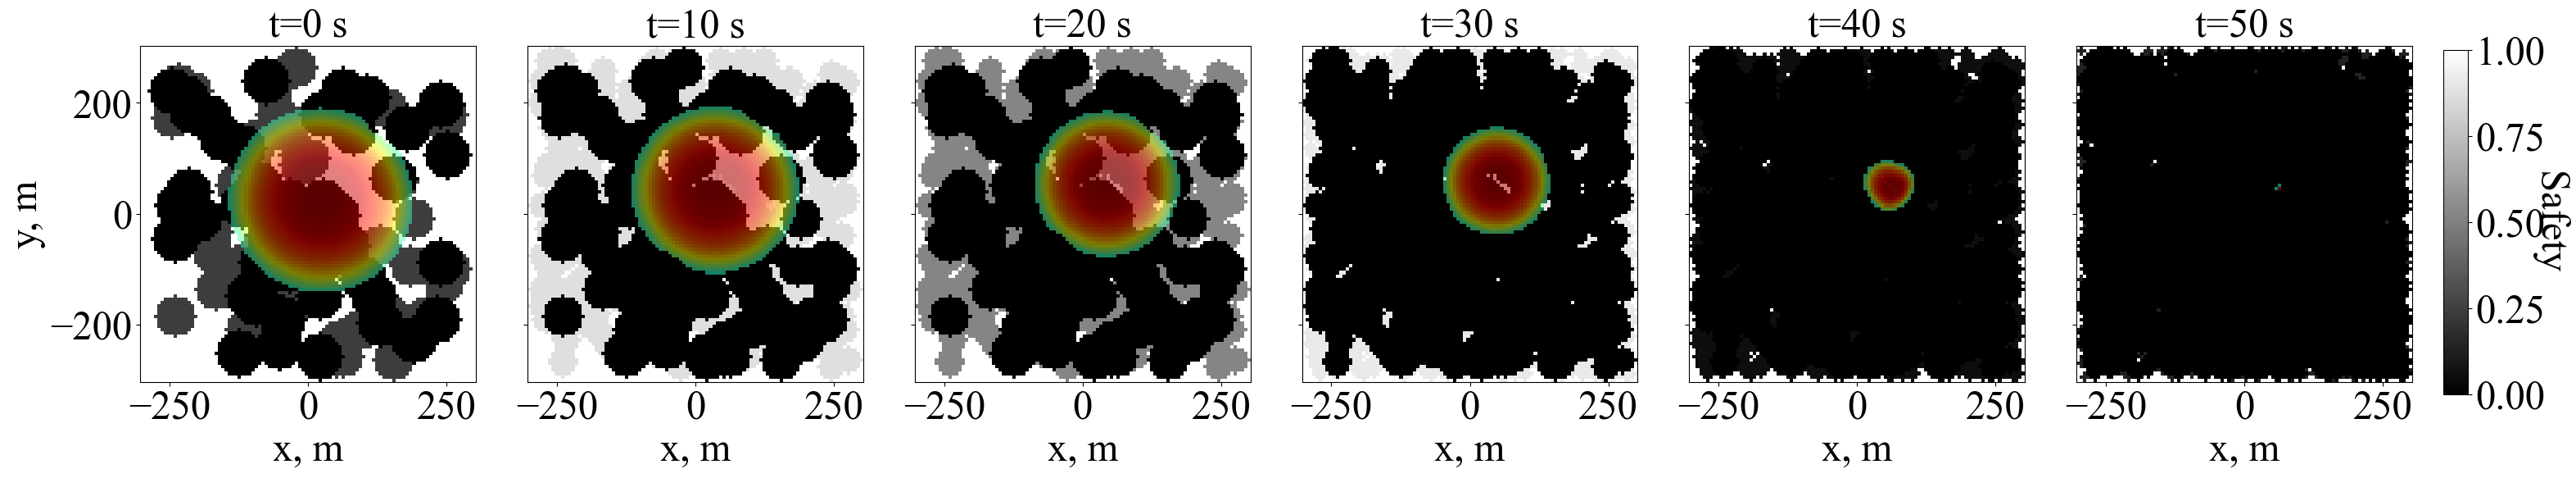

In [55]:
fig, ax = visualize_nn_reach(hda_rs, n_skip=2, fontsize=35)
fig.savefig('../saved/fig/reachset_rs.pdf', bbox_inches='tight')
# save png as well
fig.savefig('../saved/fig/reachset_rs.png', bbox_inches='tight', dpi=500)

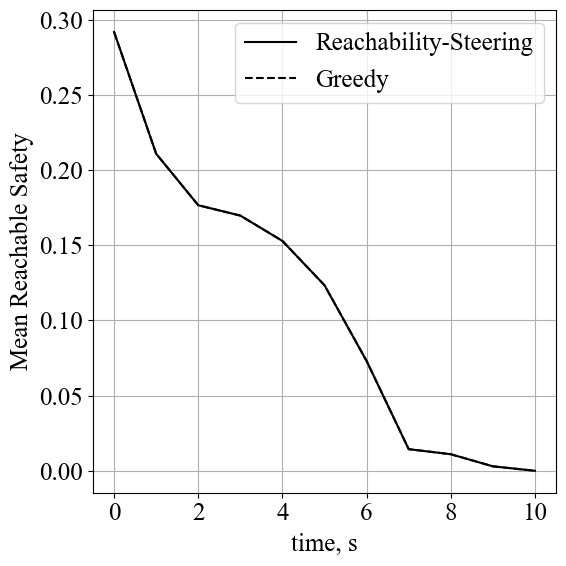

In [56]:
# font size
fontsize = 18
plt.figure(figsize=(6, 6))
plt.plot(np.arange(11), hda_rs.mean_safety_list, 'k-', label='Reachability-Steering')
plt.plot(np.arange(11), hda_greedy.mean_safety_list, 'k--', label='Greedy')
plt.xlabel('time, s', fontsize=fontsize)
plt.ylabel('Mean Reachable Safety', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.tick_params(labelsize=fontsize)
# tight layout
plt.tight_layout()
# grid
plt.grid(True)
# save
plt.savefig('../saved/fig/mean_reachable_safety.pdf')